In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [3]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [4]:
results['dataset'] = results['model_id'].apply(lambda x: x.split('_')[-5])
results = results[results['dataset'] != '1'] 
results = results[results['dataset'] != '2'] 
results = results[results['dataset'] != '3']
results['dataset'].unique()

array(['DavidEtAl', 'LiuEtAl', 'AllDatasets', 'NotGeo',
       'AllDatasetsAndNotGeo', 'LiuEtAlAndNotGeo'], dtype=object)

In [5]:
config = config[config['out_domain'] == 'yes']

In [6]:
config['dataset'].unique()

array(['DavidEtAl', 'LiuEtAl', 'AllDatasets', 'NotGeo',
       'AllDatasetsAndNotGeo', 'LiuEtAlAndNotGeo'], dtype=object)

In [7]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on=['experiment','dataset'], suffixes=('_results', '_config'))

In [8]:
df = df[(df['train_size'] == 0.9) & (df['val_size'] == 0.1)]

In [9]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

In [ ]:
df

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import ast
import numpy as np

for idx, row_data in df.iterrows():
    # Convert string representations to actual list/array objects if needed
    if isinstance(row_data['gt_values'], str):
        gt_counts = np.array(ast.literal_eval(row_data['gt_values']))
        
    if isinstance(row_data['errors'], str):
        pred_counts = np.array(ast.literal_eval(row_data['errors']))+gt_counts
    
    # Calculate metrics
    r2 = r2_score(gt_counts, pred_counts)
    rmse = root_mean_squared_error(gt_counts, pred_counts)
    mape = mean_absolute_percentage_error(gt_counts, pred_counts) *100
    
    # Update the DataFrame with the metrics
    df.at[idx, 'r_squared'] = r2
    df.at[idx, 'rmse'] = rmse
    df.at[idx, 'mape'] = mape

/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/samuelebumbaca/miniforge3/

In [32]:
# Define the mapping of dataset names to their sizes
dataset_sizes = {
    'DavidEtAl': 182,
    'LiuEtAl': 596,
    'AllDatasets': 182 + 596,
    'NotGeo': 216 + 174,
    'AllDatasetsAndNotGeo': 216 + 174 + 182 + 596
}

# Map the dataset names to their sizes and create a new column 'dataset_size'
df['dataset_size'] = df['dataset'].map(dataset_sizes)


# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model'])['r_squared'].idxmax()]

# Rename the datasets
filtered_df['dataset'] = filtered_df['dataset'].replace({
    'DavidEtAl': 'DavidEtAl.2021',
    'LiuEtAl': 'LiuEtAl.2022',
    'AllDatasets': 'scientific OOD',
    'NotGeo': 'internet OOD',
    'AllDatasetsAndNotGeo': 'All OOD',
})

# Exclude 'LiuEtAlAndNotGeo' from the DataFrame
filtered_df = filtered_df[filtered_df['dataset'] != 'LiuEtAlAndNotGeo']

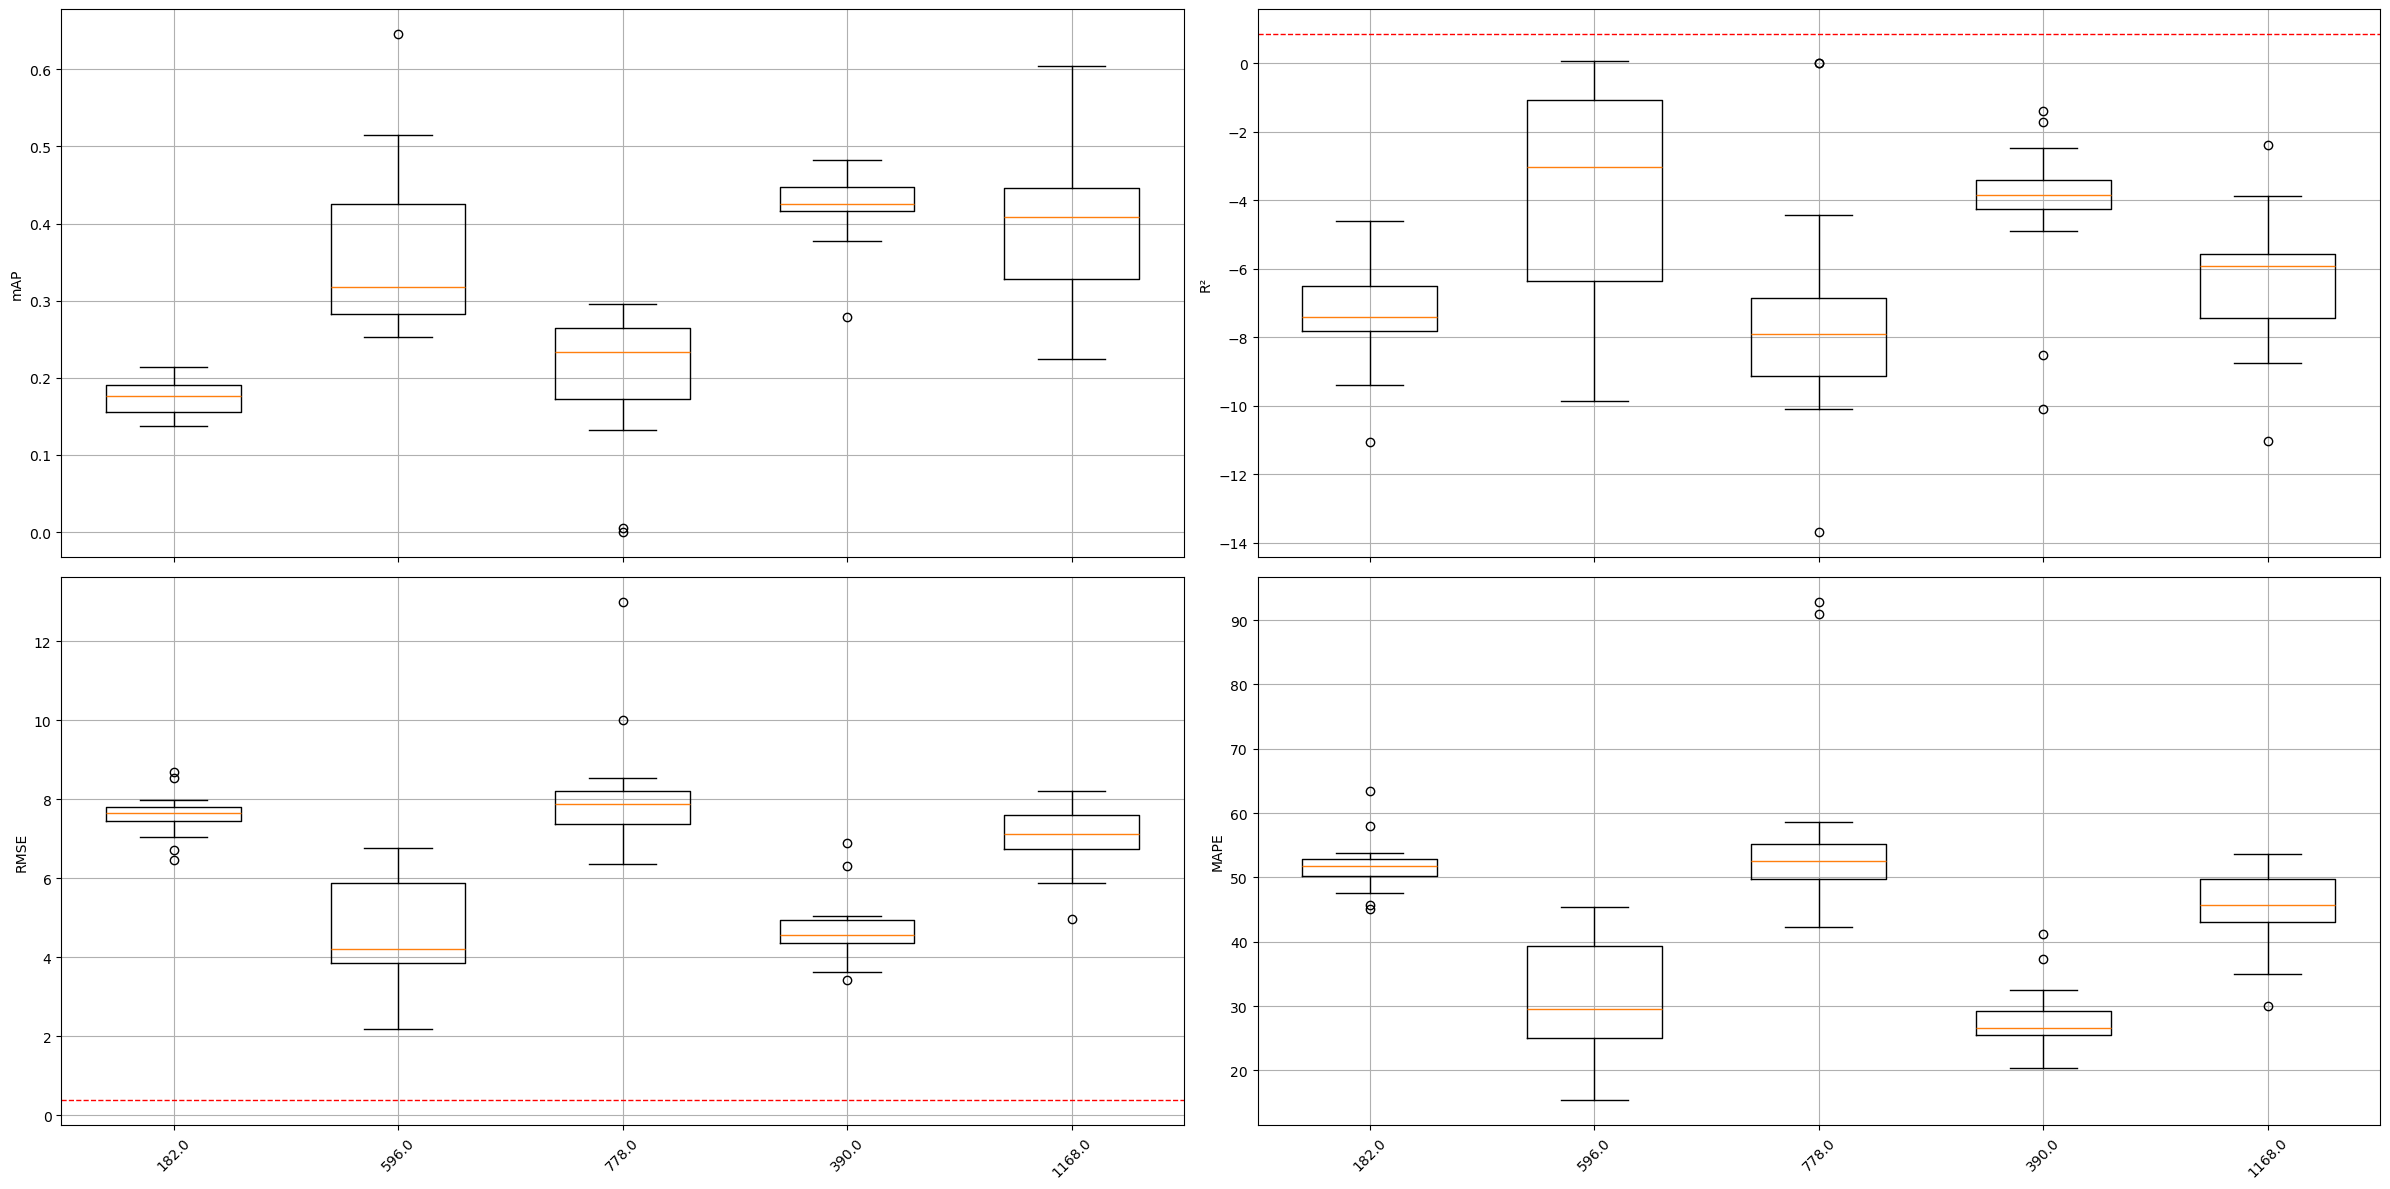

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the order of datasets
ordered_datasets = ['DavidEtAl.2021', 'LiuEtAl.2022', 'scientific OOD', 'internet OOD', 'All OOD']

# Convert the 'dataset' column to a categorical type with the specified order
filtered_df['dataset'] = pd.Categorical(filtered_df['dataset'], categories=ordered_datasets, ordered=True)

# Sort the DataFrame by the 'dataset' column
filtered_df = filtered_df.sort_values('dataset')

# Function to plot a metric
def plot_metric(ax, metric, ylabel):
    datasets = filtered_df['dataset_size'].unique()
    positions = range(len(datasets))
    for i, dataset in enumerate(datasets):
        model_data = filtered_df[filtered_df['dataset_size'] == dataset]
        ax.boxplot(model_data[metric], positions=[i], widths=0.6)
    if metric == 'r_squared':
        ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    if metric == 'rmse':
        ax.axhline(y=0.39, color='red', linestyle='--', linewidth=1)
    ax.set_xticks(positions)
    ax.set_xticklabels(datasets, rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title('')
    ax.grid(True)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(24, 12))

# Plot R-squared
plot_metric(axs[0, 0], 'ap_iou_50', 'mAP')

# Plot RMSE
plot_metric(axs[0, 1], 'r_squared', 'R²')

# Plot MAPE
plot_metric(axs[1, 0], 'rmse', 'RMSE')

# Plot mAP
plot_metric(axs[1, 1], 'mape', 'MAPE')

# Hide x-tick labels on top row
for ax in axs[0, :]:
    ax.tick_params(axis='x', labelbottom=False)
    
# Ensure x-tick labels are visible on bottom row (this is usually default)
for ax in axs[1, :]:
    ax.tick_params(axis='x', labelbottom=True)
    
# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('MDPI_template/Plots/metrics_OOD_datasets.pdf', format='pdf')

In [83]:
model_vs_model_size = {
    'yolov5nu': 1.9,
    'yolov5su': 7.2,
    'yolov5mu': 21.2,
    'yolov5lu': 46.5,
    'yolov5xu': 86.7,
    'yolov8n': 3.2,
    'yolov8s': 11.2,
    'yolov8m': 25.9,
    'yolov8l': 43.7,
    'yolov8x': 68.2,
    'yolo11n': 4.0,
    'yolo11s': 12.5,
    'yolo11m': 28.0,
    'yolo11l': 50.0,
    'yolo11x': 75.0,
    'rtdetr-l': 60.0,
    'rtdetr-x': 80.0
}

df['model_size'] = df['model'].map(dataset_sizes)

/tmp/ipykernel_35850/2422729597.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_35850/2422729597.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


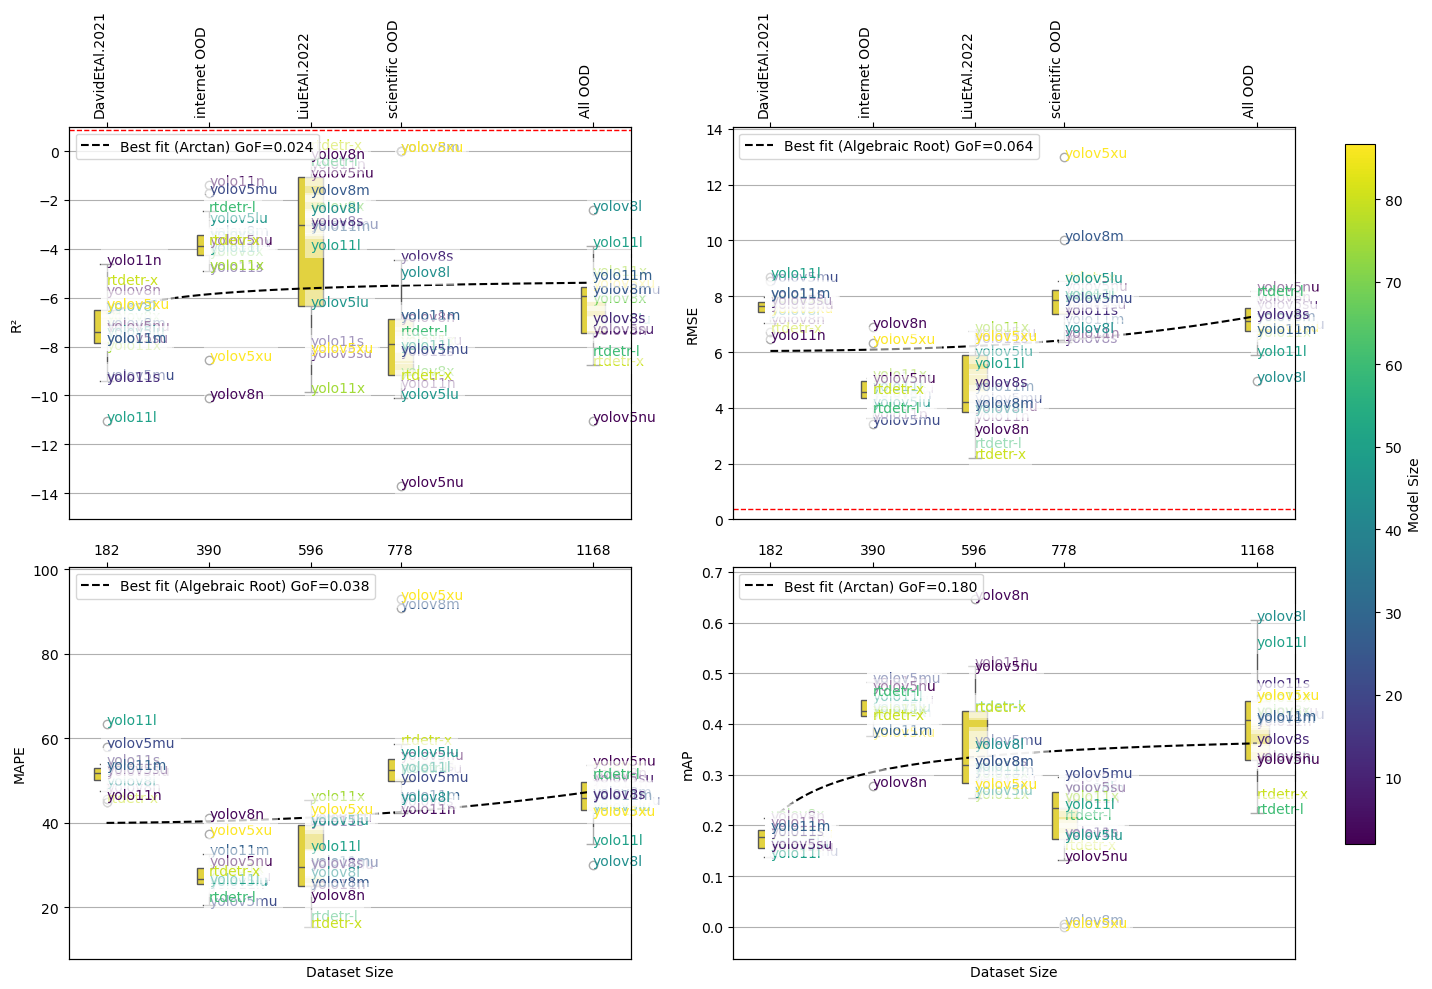

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.cm as cm

# Define the equivalence dictionary
dataset_unique_vs_dataset_sizes_unique = {
    'DavidEtAl.2021': 182,
    'LiuEtAl.2022': 596,
    'scientific OOD': 182 + 596,
    'internet OOD': 216 + 174,
    'All OOD': 216 + 174 + 182 + 596
}

# Define the metrics to plot and their new names
metrics = {
    'r_squared': 'R²',
    'rmse': 'RMSE',
    'mape': 'MAPE',
    'ap_iou_50': 'mAP'
}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axs = axs.flatten()

# Create a colormap
cmap = cm.get_cmap('viridis')
norm = plt.Normalize(vmin=min(model_vs_model_size.values()), vmax=max(model_vs_model_size.values()))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for i, (metric, metric_name) in enumerate(metrics.items()):
    for j, (dataset, size) in enumerate(dataset_unique_vs_dataset_sizes_unique.items()):
        subset = filtered_df[filtered_df['dataset_size'] == size]
        sns.boxplot(x='dataset_size', y=metric, data=subset, ax=axs[i], positions=[size], width=50, color=cmap(norm(size)))
        for _, row in subset.iterrows():
            color = cmap(norm(model_vs_model_size[row['model']]))
            axs[i].annotate(row['model'], (row['dataset_size'], row[metric]), color=color,
                            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))


    if i > 1:
        axs[i].set_xlabel('Dataset Size')
    axs[i].set_ylabel(metric_name)
    axs[i].grid(True)
    
    # Set y-axis limits
    m_min = filtered_df[metric].min()
    m_max = filtered_df[metric].max()
    m_range = abs(m_max - m_min)
    axs[i].set_ylim(m_min-m_range/10, m_max+m_range/10)

    # Set r2 and rmse benchmark thresholds
    if metric == 'r_squared':
        axs[i].axhline(y=0.85, color='red', linestyle='--', linewidth=1)
        axs[i].set_ylim(m_min-m_range/10, 1)
    if metric == 'rmse':
        axs[i].axhline(y=0.39, color='red', linestyle='--', linewidth=1)
        axs[i].set_ylim(0, m_max+m_range/10)
    
    # Fit functions for metric vs dataset_size
    x_data = filtered_df['dataset_size']
    y_data = filtered_df[metric]
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_fit = None
    best_r2_score = -np.inf
    best_fit_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_fit = y_fit_log
            best_r2_score = r2_log
            best_fit_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_fit_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_fit = y_fit_root
            best_r2_score = r2_root
            best_fit_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for the metric
    axs[i].plot(x_fit, best_fit, color='black', linestyle='--', 
                label=f'Best fit ({best_fit_name}) GoF={best_r2_score:.3f}')
    axs[i].legend(loc='upper left')

# Only show x-axis ticks on the bottom row
for ax in axs[:2]:
    ax.tick_params(axis='x', which='both', bottom=False)

# Add a second x-axis on the top
for ax in axs:
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(list(dataset_unique_vs_dataset_sizes_unique.values()))
    if ax == axs[0] or ax == axs[1]:
        ax_top.set_xticklabels(list(dataset_unique_vs_dataset_sizes_unique.keys()), rotation=90, ha='right')
    ax_top.tick_params(axis='x', which='both', top=True)

# Add colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Model Size')

plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.show()
plt.savefig('MDPI_template/Plots/metrics_OOD_datasets.pdf', format='pdf')

In [ ]:
filtered_df

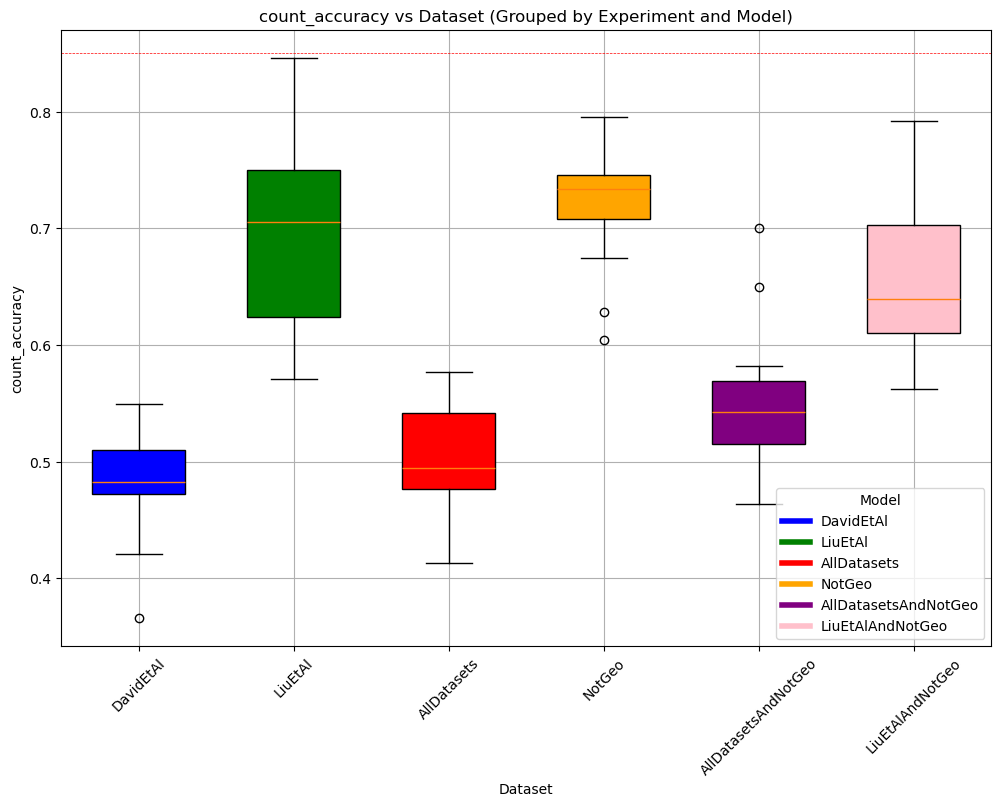

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
# filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
# filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy')
plt.title('count_accuracy vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

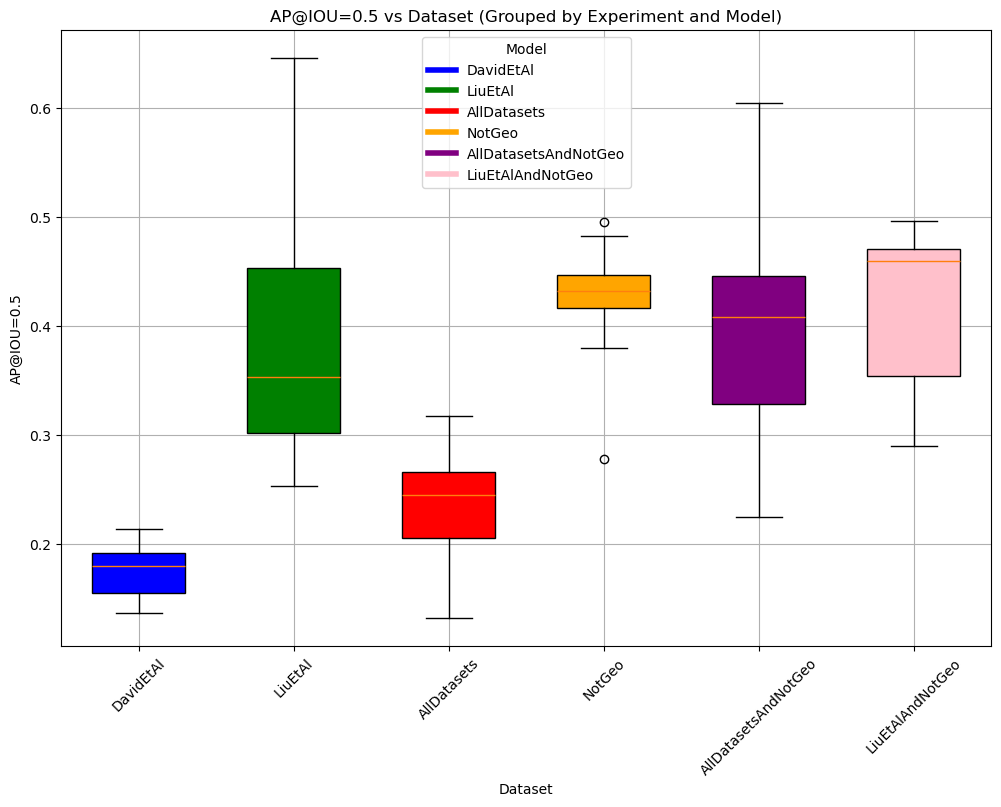

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    
plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    
plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

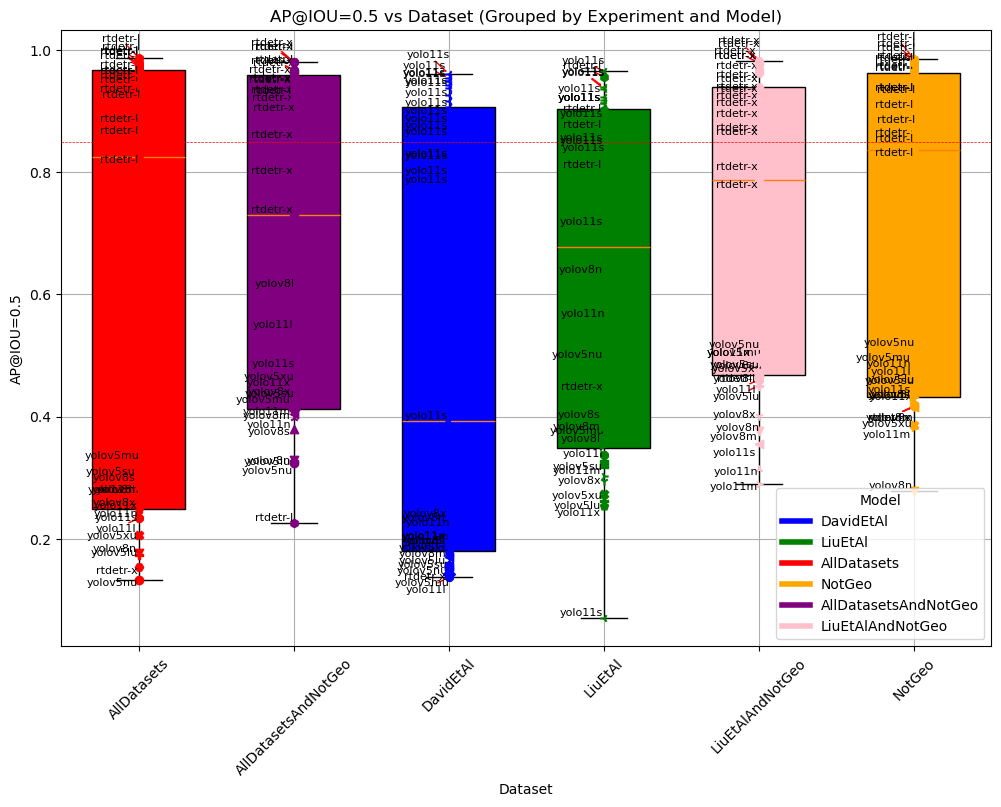

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['ap_iou_50'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
texts = []
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['ap_iou_50'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        texts.append(plt.text(i, row['ap_iou_50'], row['model'], fontsize=8, ha='right'))

# Adjust text to avoid overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('AP@IOU=0.5')
plt.title('AP@IOU=0.5 vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

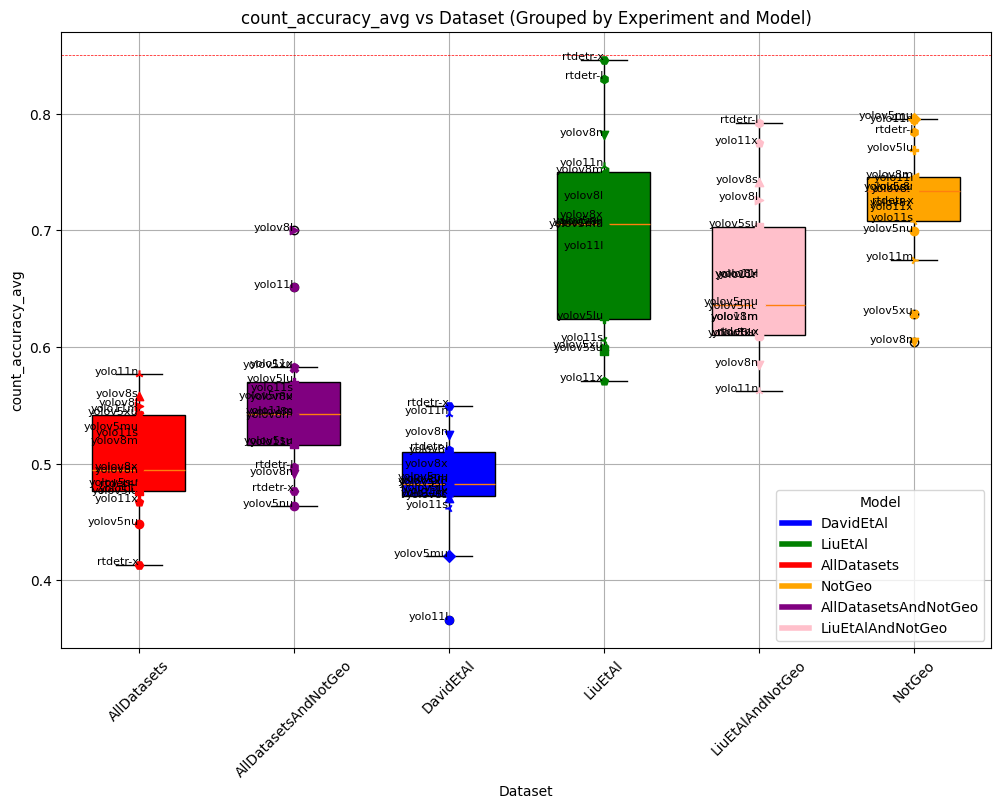

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['count_accuracy_avg'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        plt.text(i, row['count_accuracy_avg'], row['model'], fontsize=8, ha='right')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

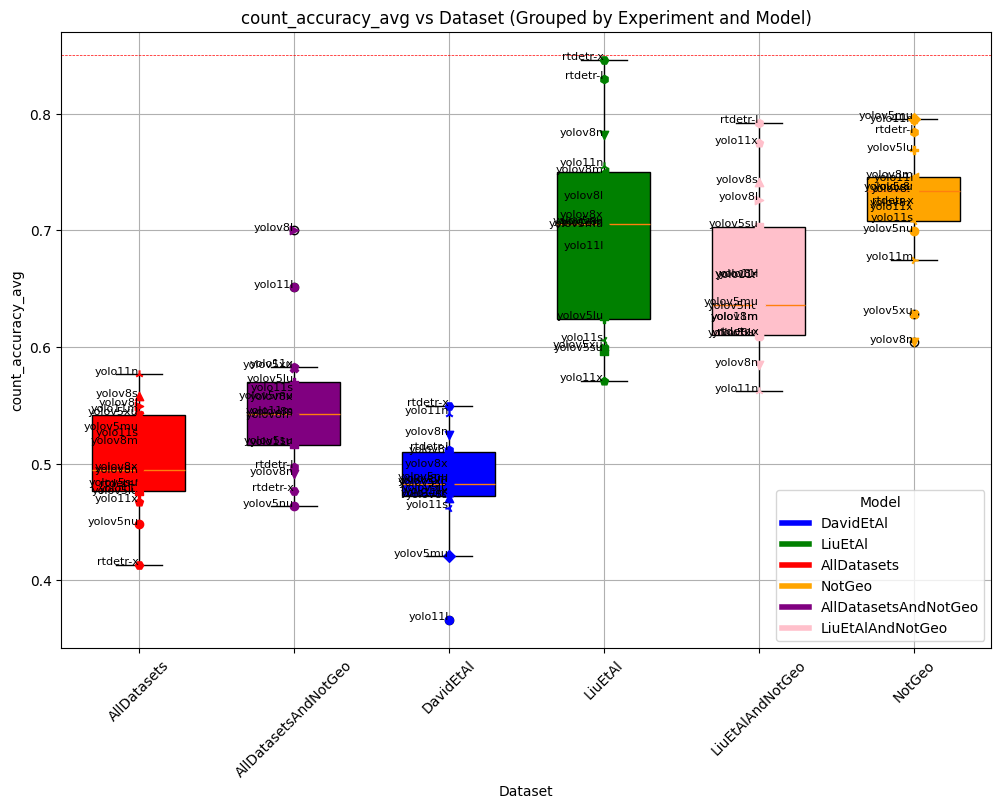

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['count_accuracy_avg'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        plt.text(i, row['count_accuracy_avg'], row['model'], fontsize=8, ha='right')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

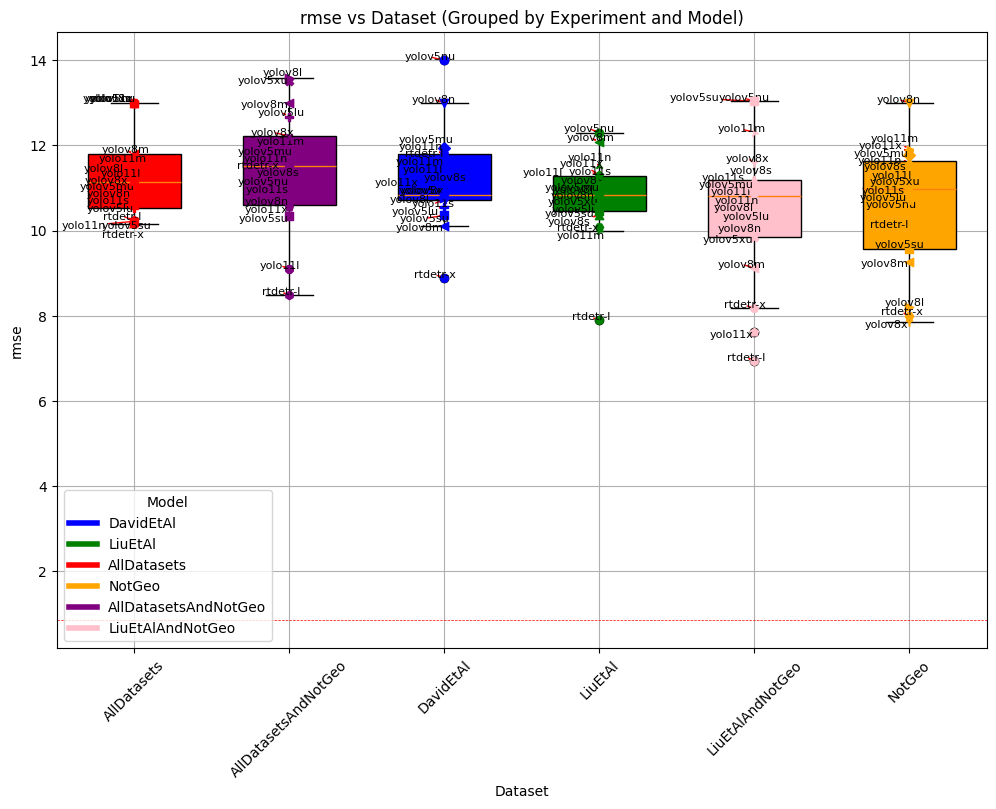

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'rmse' column to 0
filtered_df['rmse'] = filtered_df['rmse'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['rmse'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['rmse'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red', 'NotGeo': 'orange', 'AllDatasetsAndNotGeo': 'purple', 'LiuEtAlAndNotGeo': 'pink'}
simbol = {'yolov5nu': 'o', 
          'yolov5su': 's', 
          'yolov5mu': 'D', 
          'yolov5lu': 'P', 
          'yolov5xu': 'X', 
          'yolov8n': 'v',
          'yolov8s': '^',
          'yolov8m': '<',
          'yolov8l': '>',
          'yolov8x': '1',
          'yolo11n': '2',
          'yolo11s': '3',
          'yolo11m': '4',
          'yolo11l': '8',
          'yolo11x': 'p',
          'rtdetr-l': 'h',
          'rtdetr-x': 'H',}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
texts = []
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['rmse'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))
    # Plot points and label them by the variable model
    for j, row in model_data.iterrows():
        plt.scatter(i, row['rmse'], color=colors[dataset], marker=simbol[row['model']], zorder=3)
        texts.append(plt.text(i, row['rmse'], row['model'], fontsize=8, ha='right'))

# Adjust text to avoid overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('rmse')
plt.title('rmse vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()